# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 2 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2252_data_3402_001-NLyiqHJ5btv8Y/Shared%20Documents/General/Kaggle%20Tabular%20Datasets.xlsx?d=w34cdd3378d1146a2ab63700189a8c5b5&csf=1&web=1&e=6ASD5s). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please go check with Dr. Farbin to make sure it is viable.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects.

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

Shape: (480, 17)

Missing Values:
 gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

Data Types:
 gender                      object
NationalITy                 object
PlaceofBirth                object
StageID                     object
GradeID                     object
SectionID                   object
Topic                       object
Semester                    object
Relation                    object
raisedhands                  int64
VisITedResources             int64
AnnouncementsView            int64
Discussi

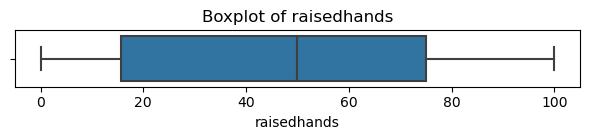

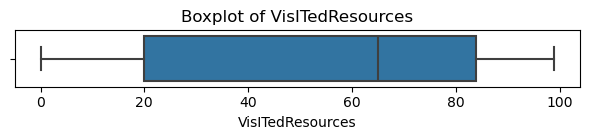

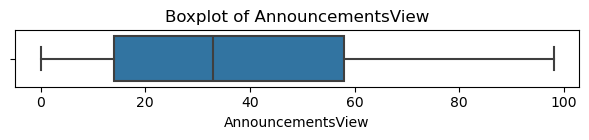

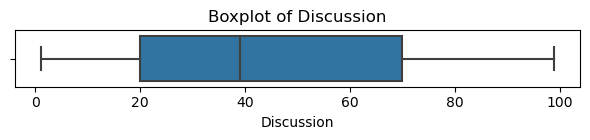

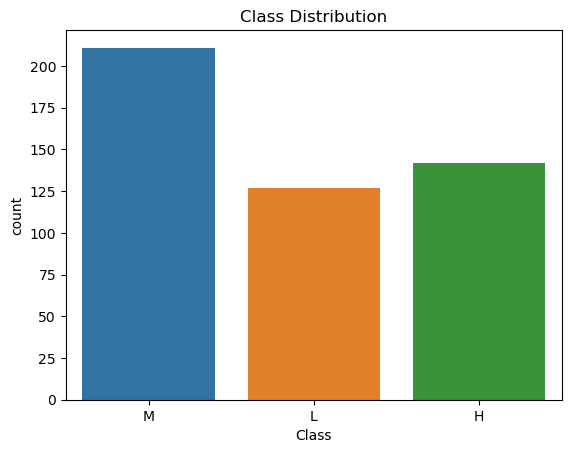

                                           Feature    Type  Unique_Values  \
gender                                      gender  object              2   
NationalITy                            NationalITy  object             14   
PlaceofBirth                          PlaceofBirth  object             14   
StageID                                    StageID  object              3   
GradeID                                    GradeID  object             10   
SectionID                                SectionID  object              3   
Topic                                        Topic  object             12   
Semester                                  Semester  object              2   
Relation                                  Relation  object              2   
raisedhands                            raisedhands   int64             82   
VisITedResources                  VisITedResources   int64             89   
AnnouncementsView                AnnouncementsView   int64             88   

In [23]:
# Step 1: Load and Explore the Data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


file_path = "\\Users\\18177\\Downloads\\xAPI-Edu-Data.csv"
df = pd.read_csv(file_path)
# Overview
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nTarget Distribution:\n", df['Class'].value_counts())
import numpy as np

# Identify numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Detect outliers using the 3-sigma rule
outlier_counts = {}
for col in numeric_cols:
    mean = df[col].mean()
    std = df[col].std()
    outliers = df[(df[col] < mean - 3 * std) | (df[col] > mean + 3 * std)]
    outlier_counts[col] = len(outliers)

# Display results
print("Outlier counts using 3-sigma rule:\n")
for col, count in outlier_counts.items():
    print(f"{col}: {count} outliers")

# Optional: show boxplots for visual inspection
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

# Step 2: Visualize Class Distribution
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

# Step 3: Encode Target for ML
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Class_encoded'] = le.fit_transform(df['Class'])

# Step 4: Summary Table for Features
summary = pd.DataFrame({
    'Feature': df.columns,
    'Type': df.dtypes.astype(str),
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Missing_Values': df.isnull().sum().values
})
print(summary)

# Step 5: Split Data for ML
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class', 'Class_encoded'])
y = df['Class_encoded']
X = pd.get_dummies(X, drop_first=True)  # One-hot encode categoricals

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)




## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.


Target Class Distribution:
 Class
M    211
H    142
L    127
Name: count, dtype: int64


C:\Users\18177\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


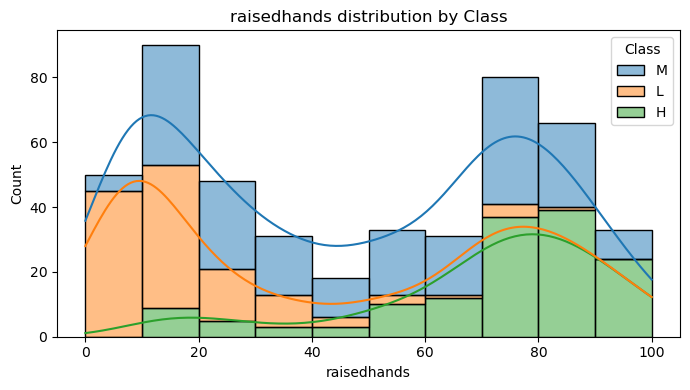

C:\Users\18177\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


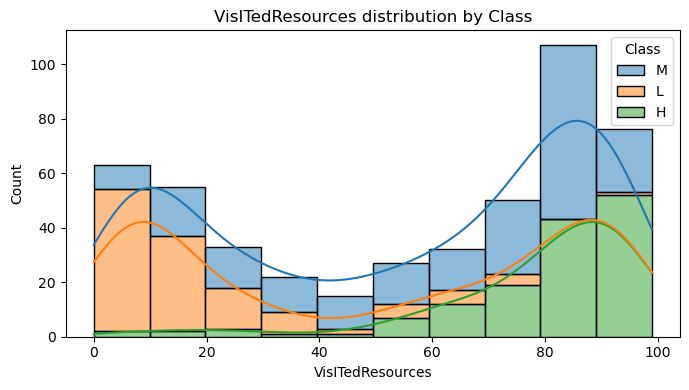

C:\Users\18177\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


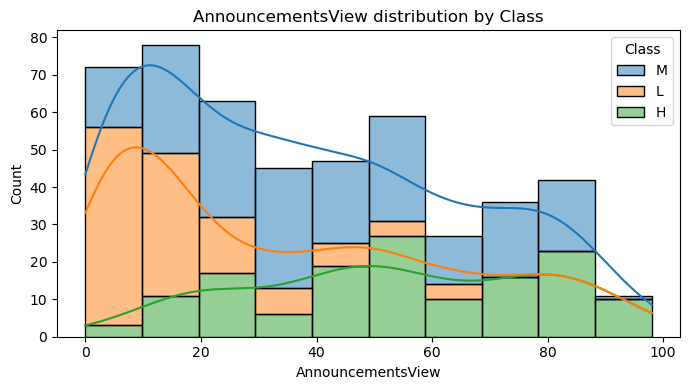

C:\Users\18177\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


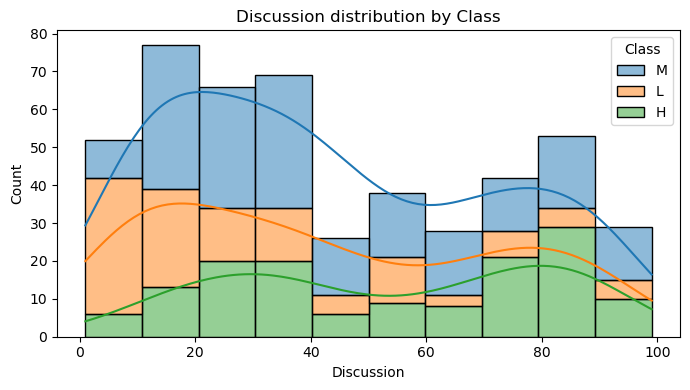

Categorical columns: ['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class']


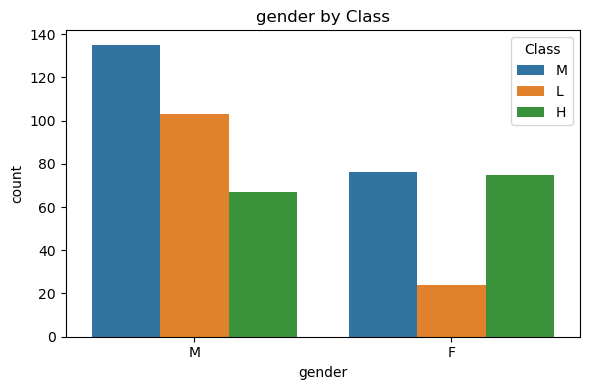

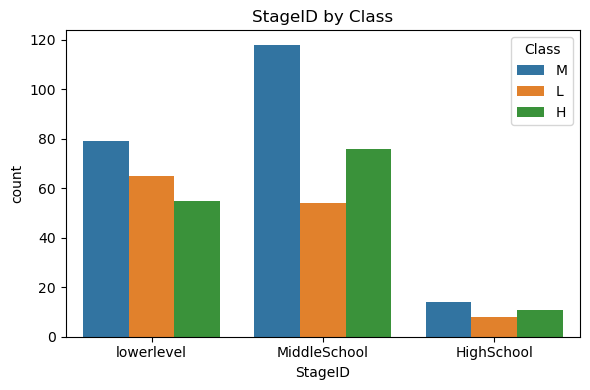

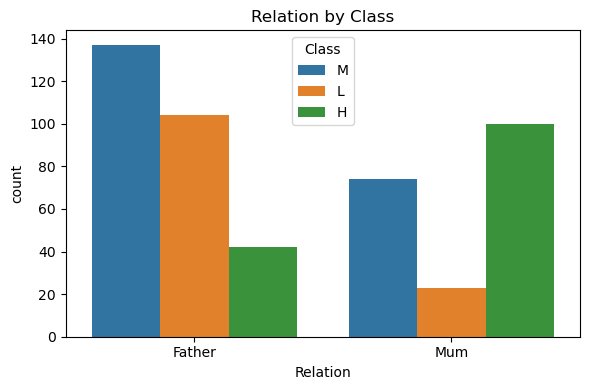

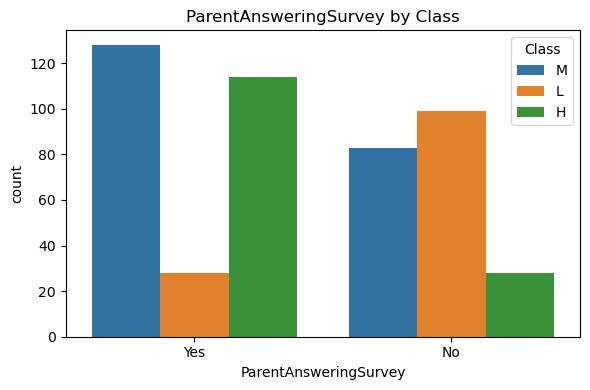

In [19]:
import pandas as pd

file_path = "\\Users\\18177\\Downloads\\xAPI-Edu-Data.csv"
df = pd.read_csv(file_path)

# Target class distribution
print("\nTarget Class Distribution:\n", df['Class'].value_counts())


import seaborn as sns
import matplotlib.pyplot as plt

# --- NUMERICAL FEATURE DISTRIBUTIONS ---
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

for feature in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=feature, hue='Class', multiple='stack', kde=True)
    plt.title(f"{feature} distribution by Class")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Check your actual categorical columns
print("Categorical columns:", df.select_dtypes(include='object').columns.tolist())

# Use only valid, existing column names
key_categoricals = ['gender', 'StageID', 'Relation', 'ParentAnsweringSurvey']

# Plot safely
for feature in key_categoricals:
    if feature in df.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x=feature, hue='Class')
        plt.title(f"{feature} by Class")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping missing feature: {feature}")



## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

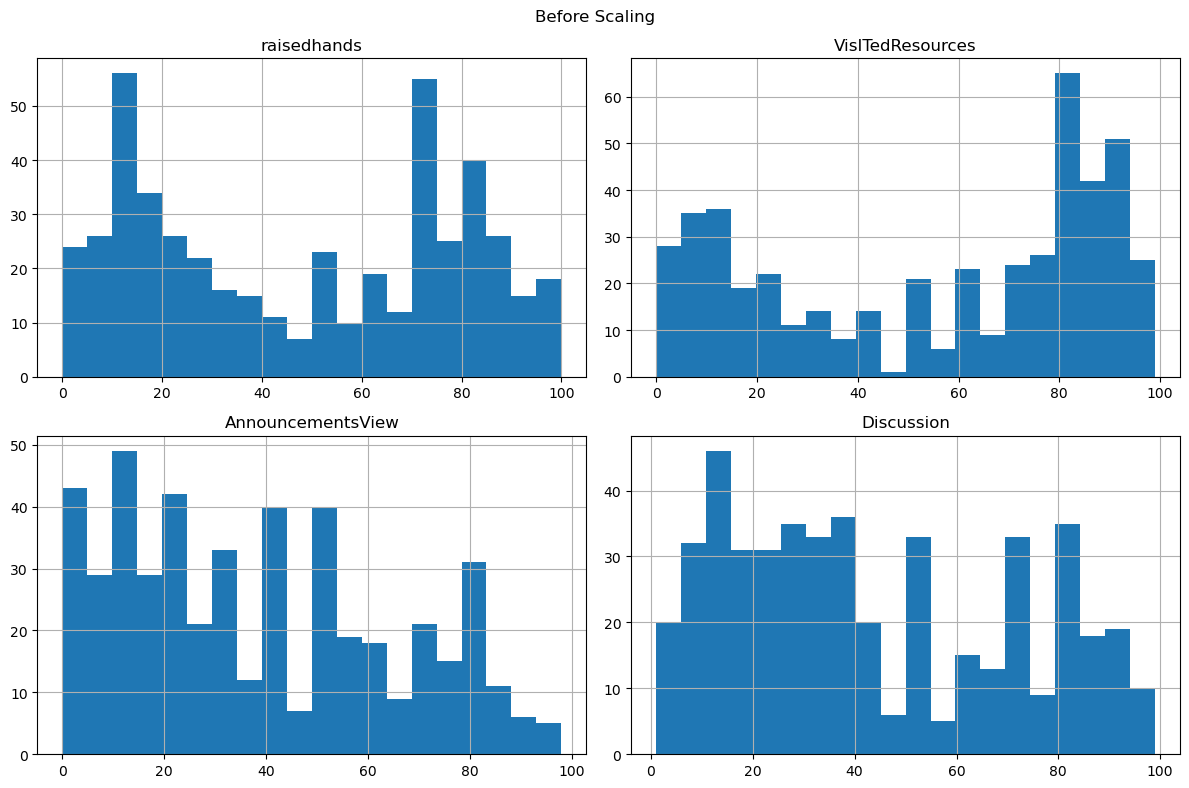

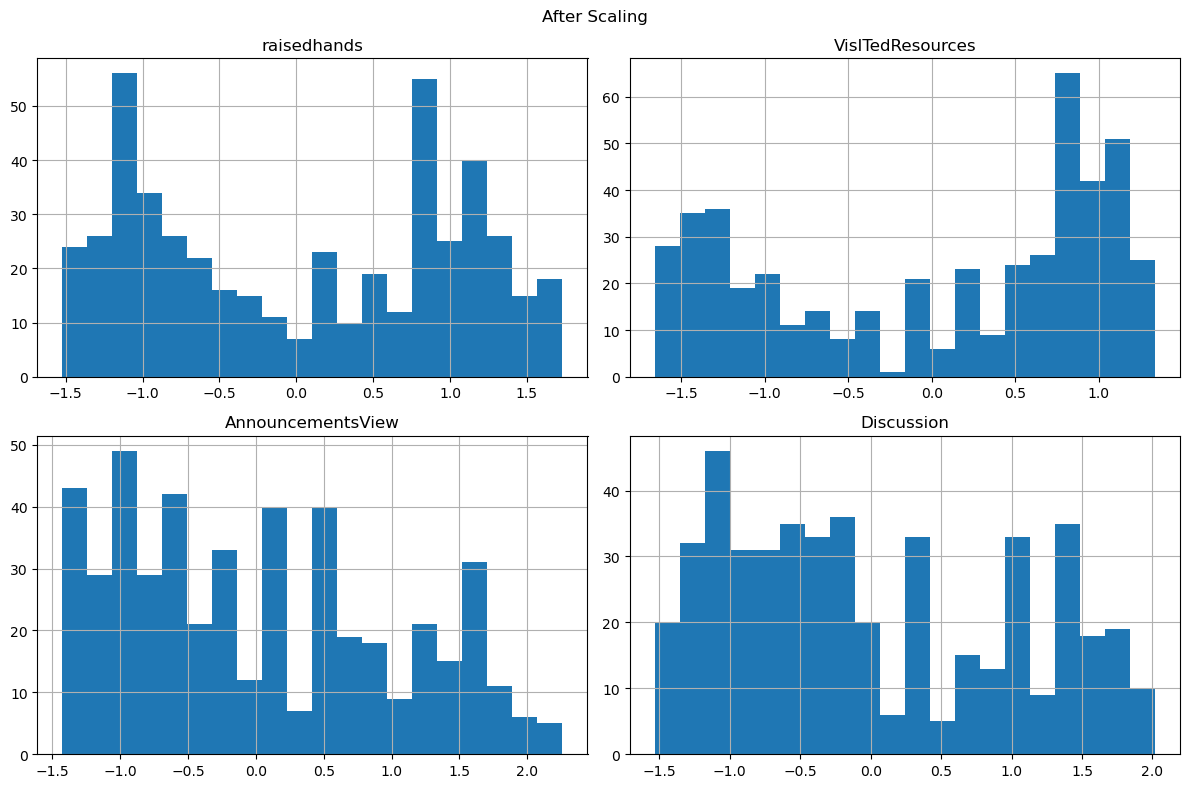

Final shape: (480, 61)
Encoded target distribution:
 Class_encoded
2    211
0    142
1    127
Name: count, dtype: int64


In [21]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Step 1: Encode the target variable
le = LabelEncoder()
df['Class_encoded'] = le.fit_transform(df['Class'])

# Step 2: One-hot encode categorical features (drop original Class)
categorical_features = df.select_dtypes(include='object').drop(columns='Class').columns.tolist()
df_encoded = pd.get_dummies(df.drop(columns=['Class']), columns=categorical_features, drop_first=True)

# Step 3: Scale numerical features
scaler = StandardScaler()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

# Visualize before scaling
df[numerical_features].hist(figsize=(12, 8), bins=20)
plt.suptitle("Before Scaling")
plt.tight_layout()
plt.show()

# Apply scaling
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

# Visualize after scaling
df_encoded[numerical_features].hist(figsize=(12, 8), bins=20)
plt.suptitle("After Scaling")
plt.tight_layout()
plt.show()

# Final check
print("Final shape:", df_encoded.shape)
print("Encoded target distribution:\n", df['Class_encoded'].value_counts())


## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Define X and y
X = df_encoded.drop(columns=['Class_encoded'])
y = df_encoded['Class_encoded']

# Step 2: Split into train, validation, test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Step 3: Train ML algorithm (Random Forest)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Step 4: Evaluate on validation set
y_val_pred = clf.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))


Validation Accuracy: 0.8020833333333334
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.88      0.85        26
           2       0.78      0.76      0.77        42

    accuracy                           0.80        96
   macro avg       0.81      0.81      0.81        96
weighted avg       0.80      0.80      0.80        96

